In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Create dummy data to prevent any data-loading errors
np.random.seed(42)
n_samples = 200

data = {
    # Categorical Columns
    'Education': np.random.choice(['High School', 'Bachelors', 'Masters', 'PhD'], n_samples),
    'City': np.random.choice(['New York', 'Paris', 'Tokyo'], n_samples),
    'Device': np.random.choice(['Mobile', 'Desktop'], n_samples),

    # Numerical Columns (with outliers and different scales)
    'Income': np.random.exponential(scale=50000, size=n_samples) + 20000, # Skewed
    'Age': np.random.normal(loc=40, scale=12, size=n_samples),           # Normally distributed
    'Experience': np.random.randint(1, 25, size=n_samples),               # Uniform-ish
    'Score1': np.random.normal(loc=500, scale=100, size=n_samples),
    'Score2': np.random.uniform(10, 100, size=n_samples),

    # Target (Binary classification)
    'Target': np.random.choice([0, 1], n_samples)
}

df = pd.DataFrame(data)
print("Initial Dataset Sample:")
display(df.head())

Initial Dataset Sample:


,Education,City,Device,Income,Age,Experience,Score1,Score2,Target
0,Masters,Tokyo,Mobile,70405.726802,43.987768,18,670.142924,77.832895,0
1,PhD,Tokyo,Desktop,22318.116201,31.018162,1,508.769948,80.992628,0
2,High School,New York,Mobile,43469.200233,58.613824,15,420.569742,25.637813,0
3,Masters,New York,Mobile,69156.249739,41.388096,8,662.076802,79.376870,0
4,Masters,Paris,Mobile,54971.972630,54.151566,11,561.738981,95.256810,0


In [ ]:
df_encoded = df.copy()

# A. LabelEncoder (Best for target variables or binary columns)
# Note: Assigns arbitrary integers. Can accidentally imply an order if used on features.
le = LabelEncoder()
df_encoded['Device_Encoded'] = le.fit_transform(df['Device'])

# B. OrdinalEncoder (Best for features with an inherent mathematical order)
# Note: Manually mapping to preserve scale (High School < Bachelors < Masters < PhD)
education_order = [['High School', 'Bachelors', 'Masters', 'PhD']]
oe = OrdinalEncoder(categories=education_order)
df_encoded['Education_Encoded'] = oe.fit_transform(df[['Education']])

# C. OneHotEncoder (Best for nominal/unordered data to prevent dummy ordering)
# Note: Creates binary dummy columns; dramatically increases dimensionality if cardinality is high.
ohe = OneHotEncoder(sparse_output=False, drop='first') # drop='first' avoids multi-collinearity
city_encoded = ohe.fit_transform(df[['City']])
city_encoded_df = pd.DataFrame(city_encoded, columns=ohe.get_feature_names_out(['City']))

# Combine all into a final feature dataframe
df_numeric_features = df_encoded[['Income', 'Age', 'Experience', 'Score1', 'Score2']]
X = pd.concat([df_numeric_features, df_encoded['Device_Encoded'], df_encoded['Education_Encoded'], city_encoded_df], axis=1)
y = df['Target']

print("Features after Encoding (Ready for Scaling):")
display(X.head())

Features after Encoding (Ready for Scaling):


,Income,Age,Experience,Score1,Score2,Device_Encoded,Education_Encoded,City_Paris,City_Tokyo
0,70405.726802,43.987768,18,670.142924,77.832895,1,2.0,0.0,1.0
1,22318.116201,31.018162,1,508.769948,80.992628,0,3.0,0.0,1.0
2,43469.200233,58.613824,15,420.569742,25.637813,1,0.0,0.0,0.0
3,69156.249739,41.388096,8,662.076802,79.376870,1,2.0,0.0,0.0
4,54971.972630,54.151566,11,561.738981,95.256810,1,2.0,1.0,0.0


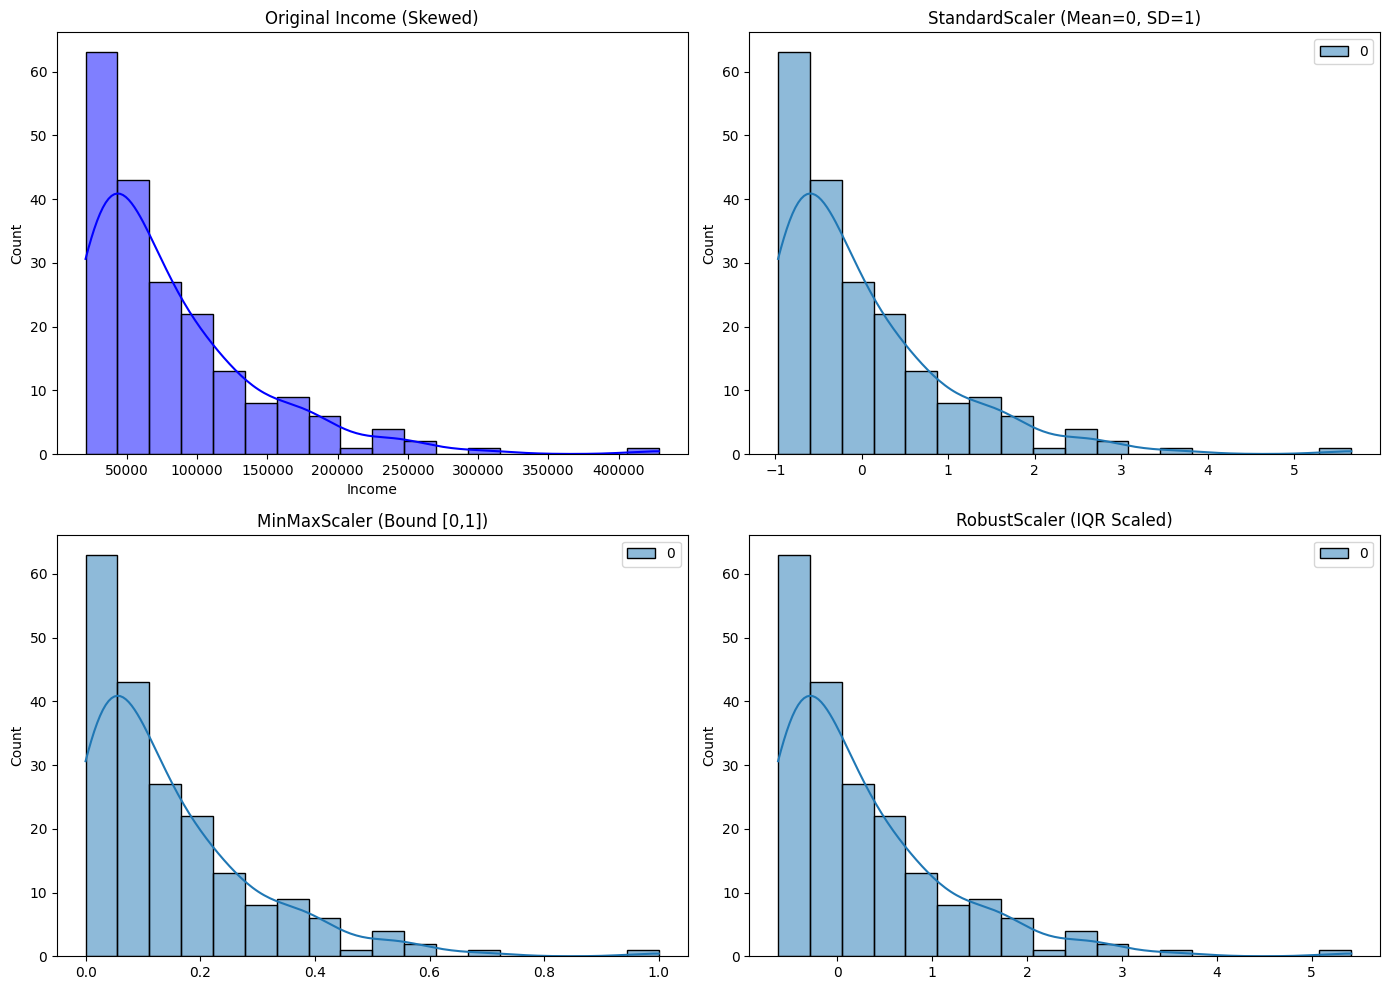

In [ ]:
# Select a highly skewed feature (Income) to show the true effect of scaling
feature_to_scale = X[['Income']]

# Initialize Scalers
scaler_std = StandardScaler()  # Centers to mean=0, var=1. Sensitive to outliers.
scaler_minmax = MinMaxScaler() # Squashes to [0, 1]. Highly affected by extreme outliers.
scaler_robust = RobustScaler() # Scales using IQR. Robust against massive outliers.

# Fit and Transform
income_std = scaler_std.fit_transform(feature_to_scale)
income_minmax = scaler_minmax.fit_transform(feature_to_scale)
income_robust = scaler_robust.fit_transform(feature_to_scale)

# Plotting Before / After Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(X['Income'], kde=True, ax=axes[0, 0], color='blue').set(title='Original Income (Skewed)')
sns.histplot(income_std, kde=True, ax=axes[0, 1], color='orange').set(title='StandardScaler (Mean=0, SD=1)')
sns.histplot(income_minmax, kde=True, ax=axes[1, 0], color='green').set(title='MinMaxScaler (Bound [0,1])')
sns.histplot(income_robust, kde=True, ax=axes[1, 1], color='red').set(title='RobustScaler (IQR Scaled)')

plt.tight_layout()
plt.show()

# Apply standard scaling across all features for the next task
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

In [ ]:
# Select top 5 features
selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X_scaled, y)

# Get selected feature names and scores
selected_indices = selector.get_support(indices=True)
feature_scores = selector.scores_[selected_indices]
selected_features = X_scaled.columns[selected_indices]

# Documenting Results
print("### FEATURE SELECTION SUMMARY ###\n")
for feat, score in zip(selected_features, feature_scores):
    print(f"Feature: {feat:<20} | F-Score: {score:.4f}")

print("\n> Documentation: SelectKBest evaluated the statistical relationship between each feature and the target.")
print("> These top 5 features matter because they possess the highest variance relationship/correlation to our target classes.")

### FEATURE SELECTION SUMMARY ###

Feature: Experience           | F-Score: 0.3314
Feature: Score1               | F-Score: 1.7198
Feature: Score2               | F-Score: 1.1090
Feature: Education_Encoded    | F-Score: 0.9451
Feature: City_Tokyo           | F-Score: 0.9936

> Documentation: SelectKBest evaluated the statistical relationship between each feature and the target.
> These top 5 features matter because they possess the highest variance relationship/correlation to our target classes.
